In [1]:
# Step 1: Imports
from ast import literal_eval
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from model.HMM import HMM
from model.label_maps import NER_TAG_TO_INDEX, INDEX_TO_NER_TAG ,NER_TAGS

In [2]:
tag_to_index = NER_TAG_TO_INDEX
index_to_tag = INDEX_TO_NER_TAG

In [3]:
# Step 2: Load dataset
df = pd.read_parquet('./data/data.parquet')
df = pd.DataFrame(df)

print('Rows:', len(df))
print('Columns:', list(df.columns))
df.head(2)

Rows: 21588
Columns: ['masked_text', 'unmasked_text', 'token_entity_labels', 'tokenised_unmasked_text']


,masked_text,unmasked_text,token_entity_labels,tokenised_unmasked_text
0,[PREFIX_1] [FIRSTNAME_1] [MIDDLENAME_1] [LASTN...,"Mr. Adolphus Reagan Ziemann, as a Central Prin...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[mr, ., adolph, ##us, reagan, z, ##ie, ##mann,..."
1,"Hello [FIRSTNAME_1], would you please investig...","Hello Hannah, would you please investigate the...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[hello, hannah, ,, would, you, please, investi..."


In [4]:
train_combined, test_combined = train_test_split(df, test_size=0.2, random_state=42)

train_df = pd.DataFrame({
    'tokens': train_combined['tokenised_unmasked_text'],
    'ner_tags': train_combined['token_entity_labels'],
})
test_df = pd.DataFrame({
    'tokens': test_combined['tokenised_unmasked_text'],
    'ner_tags': test_combined['token_entity_labels'],
})

print('Train rows:', len(train_df), 'Test rows:', len(test_df))

Train rows: 17270 Test rows: 4318


In [5]:
x_train = train_df['tokens']
y_train =[ [NER_TAG_TO_INDEX[tag] for tag in seq]
    for seq in train_df['ner_tags']
]   


x_test = test_df['tokens']
y_test = [ [NER_TAG_TO_INDEX[tag] for tag in seq]   
    for seq in test_df['ner_tags']
]



In [6]:
print ('Example tokens:', x_train[0])
print ('Example NER tags:', y_train[0])

Example tokens: ['mr' '.' 'adolph' '##us' 'reagan' 'z' '##ie' '##mann' ',' 'as' 'a'
 'central' 'principal' 'applications' 'executive' 'at' 'mclaughlin' ','
 'nad' '##er' 'and' 'pu' '##rdy' ',' 'your' 'knowledge' 'of' 'change'
 'management' 'is' 'vital' 'for' 'our' 'company' "'" 's' 'transformation'
 '.' 'we' 'request' 'you' 'to' 'create' 'a' 'change' 'management'
 'strategy' '.']
Example NER tags: [24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 3, 15, 15, 15, 15, 15, 15, 15, 15, 24]


In [7]:
vocab_to_index = {}

for seq in x_train:
    for word in seq:
        if word not in vocab_to_index:
            vocab_to_index[word] = len(vocab_to_index)

vocab_to_index['UNK'] = len(vocab_to_index)
print('Vocabulary size:', len(vocab_to_index))



Vocabulary size: 12929


In [8]:
index_to_vocab = {i: word for word, i in vocab_to_index.items()}
print('Example vocab index:', vocab_to_index['the'])

Example vocab index: 3


In [9]:

from sklearn.base import defaultdict


def threshold_data(x, threshold):
    word_freq = defaultdict(int)
    
    for seq in x:
        for word in seq:
            word_freq[word] += 1

    thresholded_x = []
    
    for seq in x:
        thresholded_seq = [
            word if word_freq[word] >= threshold else 'UNK'
            for word in seq
        ]
        thresholded_x.append(thresholded_seq)

    return thresholded_x

In [10]:
def encode_sequences(sequences, vocab_to_index):
    encoded = []
    for seq in sequences:
        encoded_seq = [
            vocab_to_index.get(word, vocab_to_index['UNK'])
            for word in seq
        ]
        encoded.append(encoded_seq)
    return encoded

In [11]:
x_train_thresh = threshold_data(x_train, threshold=1)

x_train_encoded = encode_sequences(x_train_thresh, vocab_to_index)

In [15]:
x_test_thresh = [
    [word if word in vocab_to_index else 'UNK' for word in seq]
    for seq in x_test
]

x_test_encoded = encode_sequences(x_test_thresh, vocab_to_index)

In [13]:
hmm = HMM(states=list(range(len(NER_TAGS))), vocab_to_index=vocab_to_index)

hmm.train_hmm(y_train, x_train_encoded)

In [16]:



def predict(hmm, x_test_encoded):
    predictions = []
    
    for seq in x_test_encoded:
        pred = hmm.viterbi_algorithm(seq)  # returns indices
        predictions.append(pred)
    
    return predictions


y_pred = predict(hmm, x_test_encoded)

In [17]:
def flatten(sequences):
    return [item for seq in sequences for item in seq]

y_true_flat = flatten(y_test)
y_pred_flat = flatten(y_pred)

In [24]:
from ast import literal_eval
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


def _to_list(value):
    if isinstance(value, str):
        return list(literal_eval(value))
    return list(value)


def _get_item(data, idx):
    return data.iloc[idx] if hasattr(data, 'iloc') else data[idx]


def evaluate_model(hmm_model, test_ner_tags, test_tokens,
                   n_test, ner_tag_strings, index_to_tag, vocab_to_index):
    """
    Parameters
    ----------
    hmm_model        : trained HMM instance
    test_ner_tags    : list/Series - each element is a list of integer tag ids
    test_tokens      : list/Series - each element is a list of raw token strings
    n_test           : int - how many test rows to evaluate
    ner_tag_strings  : list[str] - all NER tag names in index order, e.g. NER_TAGS
    index_to_tag     : dict[int, str] - INDEX_TO_NER_TAG
    vocab_to_index   : dict[str, int] - the vocab built from training data
                       (UNK key must be present)
    """
    true_tags_all = []
    predicted_tags_all = []

    overall_correct = 0
    overall_total = 0
    entity_correct = 0
    entity_total = 0

    for idx in range(n_test):
        tags = _to_list(_get_item(test_ner_tags, idx))
        observations = _to_list(_get_item(test_tokens, idx))
        if not observations or not tags:
            continue

        # Map test tokens to indices using the TRAINING vocab; unseen -> UNK
        unk_idx = vocab_to_index['UNK']
        observation_indices = [vocab_to_index.get(obs, unk_idx) for obs in observations]
        predicted_ids = hmm_model.viterbi_algorithm(observation_indices)

        aligned_len = min(len(tags), len(predicted_ids))
        for true_id, pred_id in zip(tags[:aligned_len], predicted_ids[:aligned_len]):
            if true_id in index_to_tag and pred_id in index_to_tag:
                true_label = index_to_tag[true_id]
                pred_label = index_to_tag[pred_id]

                true_tags_all.append(true_label)
                predicted_tags_all.append(pred_label)

                # Overall token accuracy (includes O)
                if pred_label == true_label:
                    overall_correct += 1
                overall_total += 1

                # Entity-only accuracy (excludes O)
                if true_label != 'O':
                    if pred_label == true_label:
                        entity_correct += 1
                    entity_total += 1

    overall_accuracy = overall_correct / overall_total if overall_total > 0 else 0.0
    entity_accuracy = entity_correct / entity_total if entity_total > 0 else 0.0
    print(f'Overall token accuracy (includes O): {overall_accuracy:.4f}')
    print(f'Entity-only accuracy (excludes O): {entity_accuracy:.4f}')

    compute_metrics(true_tags_all, predicted_tags_all, ner_tag_strings)
    plot_misclassification_rates(ner_tag_strings, true_tags_all, predicted_tags_all)


def compute_metrics(true_tags, predicted_tags, ner_tag_strings):
    states_no_o = [s for s in ner_tag_strings if s not in ('O', 'UNK')]

    print("\nOverall Metrics (excluding 'O'):")
    print(classification_report(true_tags, predicted_tags,
                                 zero_division=1, labels=states_no_o))

    per_state_report = classification_report(
        true_tags, predicted_tags,
        labels=states_no_o, output_dict=True, zero_division=1
    )

    precision_values = [per_state_report[s]['precision'] for s in states_no_o]
    recall_values = [per_state_report[s]['recall'] for s in states_no_o]
    f1_values = [per_state_report[s]['f1-score'] for s in states_no_o]
    support_values = [per_state_report[s]['support'] for s in states_no_o]
    state_accuracy_values = [
        sum(1 for t, p in zip(true_tags, predicted_tags) if t == s and p == s)
        / true_tags.count(s)
        if true_tags.count(s) > 0 else 0
        for s in states_no_o
    ]

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
    fig.suptitle("Metrics Comparison for Different Entity Types (excluding 'O')", fontsize=16)

    axes[0, 0].bar(states_no_o, precision_values, color='skyblue')
    axes[0, 0].set_title('Precision')
    axes[0, 0].tick_params(axis='x', rotation=90)

    axes[0, 1].bar(states_no_o, recall_values, color='lightcoral')
    axes[0, 1].set_title('Recall')
    axes[0, 1].tick_params(axis='x', rotation=90)

    axes[1, 0].bar(states_no_o, f1_values, color='lightgreen')
    axes[1, 0].set_title('F1-Score')
    axes[1, 0].tick_params(axis='x', rotation=90)

    support_bars = axes[1, 1].bar(states_no_o, support_values, color='gold')
    axes[1, 1].set_title('Support')
    axes[1, 1].tick_params(axis='x', rotation=90)
    for bar, sv in zip(support_bars, support_values):
        axes[1, 1].text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.1,
                        str(int(sv)), ha='center', va='bottom')

    axes[2, 0].bar(states_no_o, state_accuracy_values, color='orchid')
    axes[2, 0].set_title('State-wise Accuracy')
    axes[2, 0].tick_params(axis='x', rotation=90)
    fig.delaxes(axes[2, 1])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\nConfusion Matrix (excluding 'O'):")
    conf_matrix = confusion_matrix(true_tags, predicted_tags, labels=states_no_o)
    plt.figure(figsize=(16, 10))
    sns.heatmap(conf_matrix, annot=True, fmt='d',
                xticklabels=states_no_o, yticklabels=states_no_o)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title("Confusion Matrix (excluding 'O')")
    plt.show()


def plot_misclassification_rates(ner_tag_strings, true_tags, predicted_tags):
    states = [s for s in ner_tag_strings if s not in ('O', 'UNK')]

    misclassification_counts = {s: 0 for s in states}
    for true_tag, pred_tag in zip(true_tags, predicted_tags):
        if true_tag in misclassification_counts and true_tag != pred_tag:
            misclassification_counts[true_tag] += 1

    misclassification_rates = {
        s: misclassification_counts[s] / true_tags.count(s)
        if true_tags.count(s) > 0 else 0
        for s in states
    }

    sorted_states = sorted(states,
                           key=lambda s: misclassification_rates[s],
                           reverse=True)
    plt.figure(figsize=(10, 6))
    plt.bar(sorted_states,
            [misclassification_rates[s] for s in sorted_states],
            color='coral')
    plt.xticks(rotation=90)
    plt.xlabel('Entity Types')
    plt.ylabel('Misclassification Rate')
    plt.title('Misclassification Rates for Different Entity Types')
    plt.tight_layout()
    plt.show()

Overall token accuracy (includes O): 0.8884
Entity-only accuracy (excludes O): 0.6488

Overall Metrics (excluding 'O'):
                    precision    recall  f1-score   support

     B-ACCOUNTNAME       0.89      0.98      0.93       206
   B-ACCOUNTNUMBER       0.12      0.02      0.03       210
B-CREDITCARDNUMBER       0.29      0.95      0.45       205
           B-EMAIL       0.71      0.81      0.75       300
              B-IP       0.00      0.00      0.00       181
            B-IPV4       0.66      0.94      0.78       242
            B-IPV6       0.25      0.75      0.37       196
             B-MAC       0.68      0.34      0.46       189
        B-PASSWORD       0.18      0.44      0.25       209
    B-PHONE_NUMBER       0.37      0.90      0.52       219
             B-SSN       0.95      0.22      0.35       175
        B-USERNAME       0.56      0.19      0.28       279
     I-ACCOUNTNAME       0.88      1.00      0.93       355
   I-ACCOUNTNUMBER       0.13      0.02

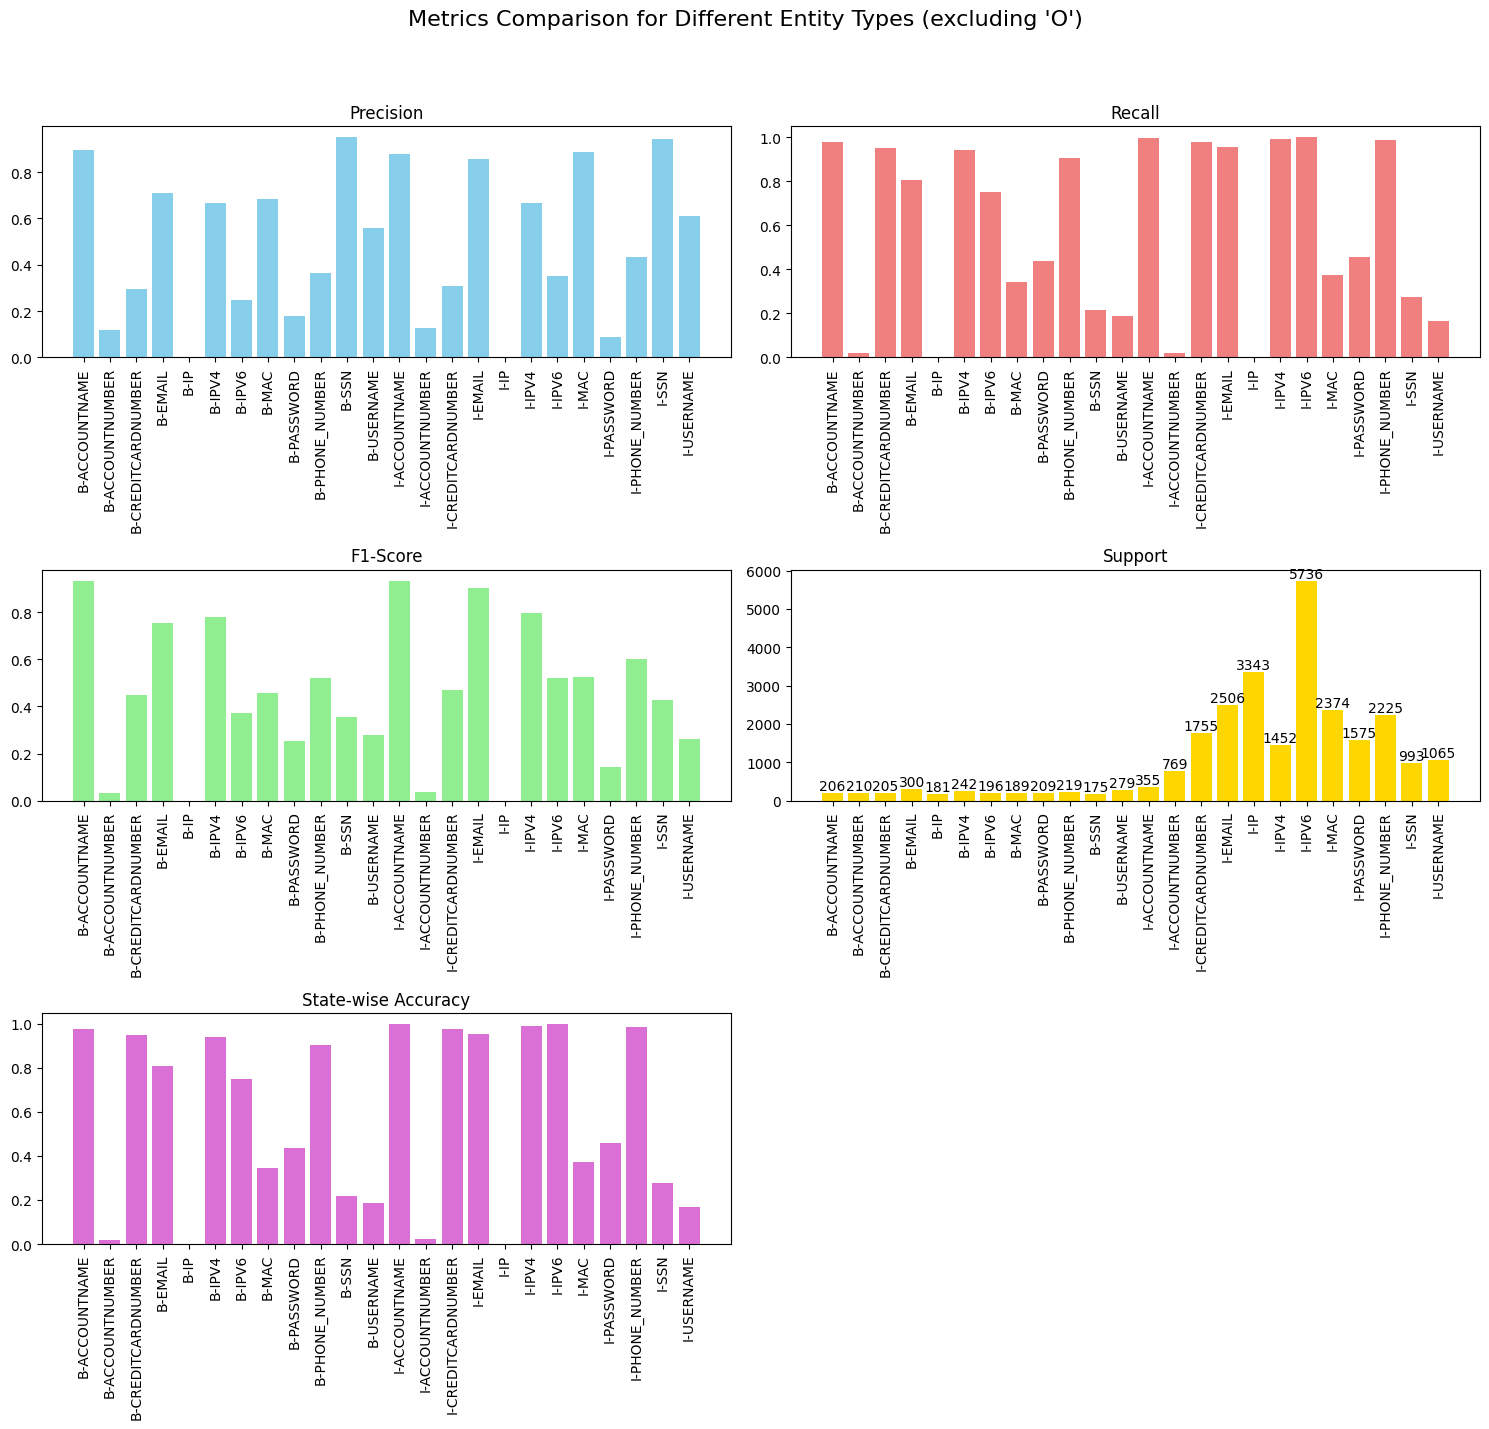


Confusion Matrix (excluding 'O'):


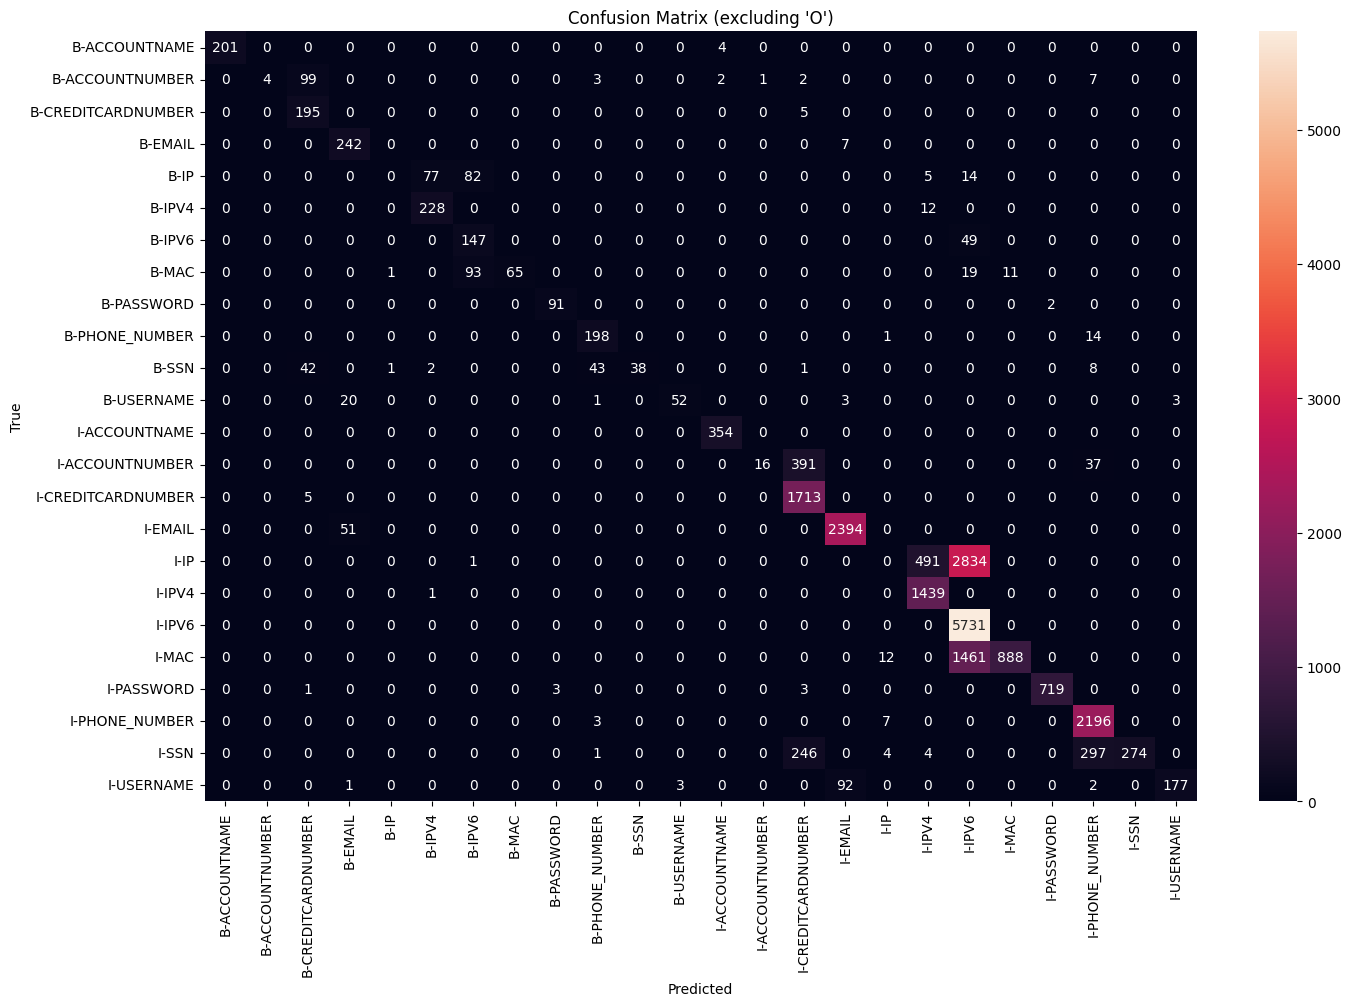

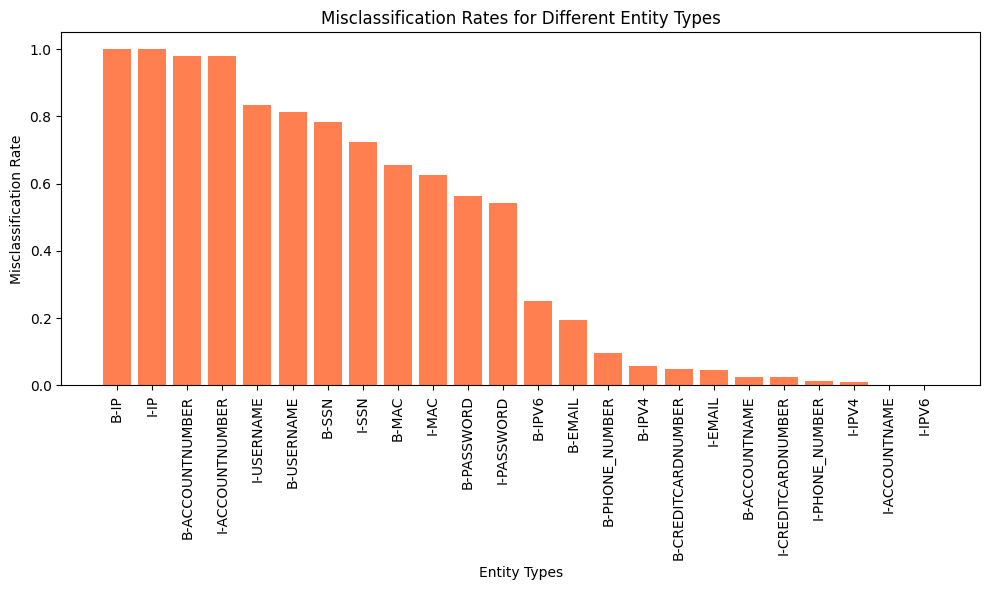

In [25]:
evaluate_model(
    hmm_model=hmm,
    test_ner_tags=y_test,            # use numeric ground truth labels
    test_tokens=x_test,              # raw tokens
    n_test=len(y_test),
    ner_tag_strings=NER_TAGS,
    index_to_tag=INDEX_TO_NER_TAG,
    vocab_to_index=vocab_to_index,
 )